In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# 1. Sütun isimlerini tanımlama (Orijinal veride başlık satırı yoktur)
columns = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight",
    "engine-type", "num-of-cylinders", "engine-size", "fuel-system",
    "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
    "city-mpg", "highway-mpg", "price"
]

In [3]:
# 2. Veriyi doğrudan UCI deposundan okuma
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
df = pd.read_csv(url, names=columns)

In [4]:
# 3. Eksik değerleri '?' temizleme ve sayısal tipe dönüştürme
df.replace('?', np.nan, inplace=True)

In [5]:
# İnceleyeceğimiz sayısal sütunları dönüştürelim
features_to_convert = ['horsepower', 'engine-size', 'curb-weight', 'price']
for col in features_to_convert:
    df[col] = pd.to_numeric(df[col])

In [6]:
# Hedef değişkende (price) veya özelliklerde boş olan satırları çıkaralım
df_clean = df.dropna(subset=features_to_convert)

In [7]:
# 4. Bağımsız (X) ve Bağımlı (y) Değişkenleri Belirleme
# Örnek olarak motor gücü (horsepower) ile fiyat (price) tahmini:
X = df_clean[['horsepower']]  # Çoklu regresyon için: df_clean[['horsepower', 'engine-size', 'curb-weight']]
y = df_clean['price']

In [8]:
# 5. Train-Test Bölünmesi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# 6. Model Eğitimi
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
# 7. Tahmin ve Metrikler
y_pred = model.predict(X_test)

print(f"Eğim (Katsayı): {model.coef_[0]:.2f}")
print(f"Kesişim (Intercept): {model.intercept_:.2f}")
print(f"R² Skoru: {r2_score(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

Eğim (Katsayı): 155.61
Kesişim (Intercept): -3194.29
R² Skoru: 0.60
RMSE: 6761.21


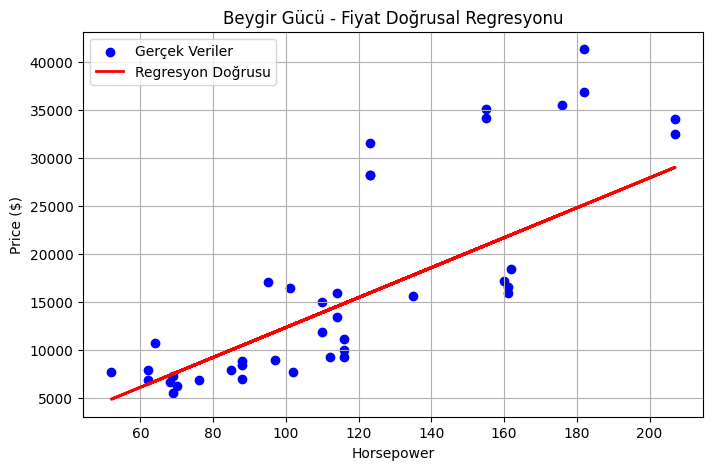

In [11]:
# 8. Regresyon Doğrusunun Görselleştirilmesi
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', label='Gerçek Veriler')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regresyon Doğrusu')
plt.title('Beygir Gücü - Fiyat Doğrusal Regresyonu')
plt.xlabel('Horsepower')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()